In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from constants import *
from preprocessing import load_house_df

import warnings
warnings.filterwarnings("ignore")

set_project_theme()
pd.set_option("display.width", 120)
%matplotlib inline

In [2]:
house_df = load_house_df()
house_df.head()

,international,age,semesters_completed,commute_distance_km,financial_need_score,housing_urgency_rating,grades,should_recieve_housing,HO,A1,A2,A3,A4,grades_raw,grade_format,international_bin,age_group
0,domestic,26,2,31.1,62.93,5.8,46.488294,1,1,0,1,0,0,4.34,numeric_0_10,0,25 or older
1,domestic,27,5,13.2,66.45,5.9,61.705686,1,1,0,1,1,0,4.83,numeric_0_10,0,25 or older
2,domestic,25,5,9.8,50.23,5.2,50.063158,1,0,0,0,0,0,NaN,missing,0,25 or older
3,domestic,21,2,20.2,56.99,5.7,3.631151,1,1,0,0,1,0,2.06,numeric_0_10,0,under 25
4,domestic,34,7,51.9,32.31,4.6,43.430483,0,0,0,0,0,0,4.24,numeric_0_10,0,25 or older


# Section 4.1: Predictive Parity

Predictive parity asks whether the target is independent of the sensitive group once we know the decision,
$T \perp G \mid S$. We check it on both sides of the decision:

- among the **selected** students ($S=1$): `a` is the value for group 1, `b` for group 0.
- among the **not selected** students ($S=0$): `c` is the value for group 1, `d` for group 0.

The assignment defines predictive parity as the selected side only, so `fair_selected` (based on $|a-b|$) is the
verdict we report. `fair_both` is the stricter version that also requires $|c-d|$ inside the margin, and we keep it
as extra evidence. Margin is 5 percentage points, so 0.05 still counts as fair.

In [3]:
sensitive_features

['age', 'international']

### Predective Parity ($G \perp T \mid S$)

In [4]:
def calculate_predictive_parity_fairness(G, T, predictors, margin=MARGIN):
    n_group_1, n_group_0 = sum(G == 1), sum(G == 0)
    assert n_group_1 > 0 and n_group_0 > 0, f'one group is empty: n1={n_group_1}, n0={n_group_0}'
    print(f'group 1: {n_group_1} students, group 0: {n_group_0} students')

    predictive_parity_fairness = pd.DataFrame(
        index=predictors,
        columns=['fair_selected', 'fair_both', 'a', 'b', 'c', 'd', '|a-b|', '|c-d|', 'n_sel_1', 'n_sel_0'])

    for predictor in predictors:
        S = house_df[predictor]
        try: a = sum((G==1)*(T==1)*(S==1)) / sum((S==1) * (G==1))
        except: a = 0
        try: b = sum((G==0)*(T==1)*(S==1)) / sum((S==1) * (G==0))
        except: b = 0

        try: c = sum((G==1)*(T==1)*(S==0)) / sum((S==0) * (G==1))
        except: c = 0

        try: d = sum((G==0)*(T==1)*(S==0)) / sum((S==0) * (G==0))
        except: d = 0

        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['a',] ] = a
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['b',] ] = b
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['c',] ] = c
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['d',] ] = d
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['|a-b|',] ] = abs(a - b)
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['|c-d|',] ] = abs(c - d)
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['fair_selected',] ] = (abs(a - b) <= margin)
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['fair_both',] ] = (abs(a - b) <= margin) * (abs(c - d) <= margin)
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['n_sel_1',] ] = sum((S==1) * (G==1))
        predictive_parity_fairness.loc[ predictive_parity_fairness.index == predictor, ['n_sel_0',] ] = sum((S==1) * (G==0))

    return predictive_parity_fairness.astype(float).round(3)

### Age

Group 1 is **under 25** and group 0 is **25 or older**, as defined in the assignment, so the split is `age < 25`
and not `age <= 25` (there are 217 students who are exactly 25).

In [5]:
G = house_df.age < 25
T = house_df.should_recieve_housing
predictors = ['HO', 'A1', 'A2', 'A3', 'A4']

In [6]:
pp_age = calculate_predictive_parity_fairness(G, T, predictors)
pp_age

group 1: 1088 students, group 0: 1412 students


,fair_selected,fair_both,a,b,c,d,|a-b|,|c-d|,n_sel_1,n_sel_0
HO,1.0,1.0,0.776,0.819,0.069,0.101,0.044,0.033,637.0,288.0
A1,0.0,0.0,0.834,0.664,0.299,0.141,0.169,0.159,373.0,289.0
A2,0.0,0.0,0.799,0.581,0.178,0.086,0.218,0.092,533.0,461.0
A3,0.0,0.0,0.861,0.728,0.246,0.112,0.134,0.134,418.0,312.0
A4,1.0,1.0,0.868,0.908,0.179,0.156,0.039,0.023,479.0,173.0


A1 (0.169), A2 (0.218) and A3 (0.134) fail by a wide margin. For A2, 80 percent of the selected students under 25
should really receive housing against only 58 percent of the selected older ones, so A2 is too generous with older
applicants compared to the target. HO (0.044) and A4 (0.039) pass.

The `|c-d|` column agrees for HO and A4, so their verdict does not depend on which version of the definition we
use.

### International

Group 1 is **international** and group 0 is **domestic**. The column is text, so we build a boolean mask, otherwise
`G==1` is never true and every cell comes out as 0.

In [7]:
print(house_df.international.unique())

G = house_df.international == 'international'
T = house_df.should_recieve_housing
print('international:', sum(G == 1), ' domestic:', sum(G == 0))

['domestic' 'international']
international: 593  domestic: 1907


In [8]:
pp_international = calculate_predictive_parity_fairness(G, T, predictors)
pp_international

group 1: 593 students, group 0: 1907 students


,fair_selected,fair_both,a,b,c,d,|a-b|,|c-d|,n_sel_1,n_sel_0
HO,0.0,0.0,0.849,0.763,0.133,0.082,0.086,0.051,284.0,641.0
A1,1.0,1.0,0.760,0.760,0.236,0.195,0.001,0.041,271.0,391.0
A2,1.0,0.0,0.672,0.716,0.058,0.129,0.043,0.071,403.0,591.0
A3,1.0,0.0,0.795,0.808,0.267,0.136,0.014,0.131,234.0,496.0
A4,0.0,0.0,0.916,0.859,0.202,0.154,0.057,0.048,227.0,425.0


The result is the opposite of the age one. A1 (0.001), A3 (0.014) and A2 (0.043) pass, while HO fails with 0.086
and A4 fails narrowly with 0.057.

For HO, 85 percent of the selected international students should really receive housing against 76 percent of the
selected domestic ones, so an international student has to be a more obvious case before the officer says yes.

A4 at 0.057 sits right next to the 0.05 line. With a 6 point margin it would be called fair, which is a concrete
example of the bias washing problem mentioned in the assignment footnote.

On the stricter version A2 and A3 also fail, because their `|c-d|` is 0.071 and 0.131. So among the students they
refused, the international ones are treated differently from the domestic ones even though the selected side looks
balanced.

### Both sensitive features together

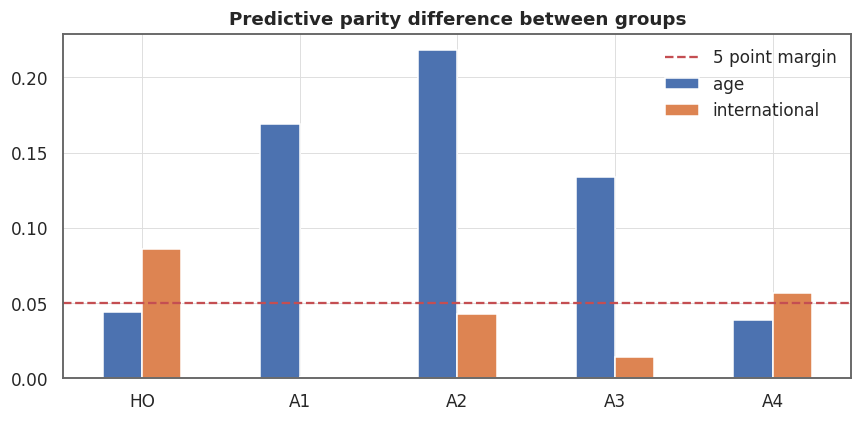

,age |a-b|,age fair,intl |a-b|,intl fair
HO,0.044,1.0,0.086,0.0
A1,0.169,0.0,0.001,1.0
A2,0.218,0.0,0.043,1.0
A3,0.134,0.0,0.014,1.0
A4,0.039,1.0,0.057,0.0


In [9]:
summary_pp = pd.DataFrame({
    'age |a-b|': pp_age['|a-b|'],
    'age fair': pp_age['fair_selected'],
    'intl |a-b|': pp_international['|a-b|'],
    'intl fair': pp_international['fair_selected'],
})

plot_pp = pd.DataFrame({'age': pp_age['|a-b|'], 'international': pp_international['|a-b|']})
plot_pp.plot(kind='bar', figsize=(8, 4), rot=0)
plt.axhline(0.05, color=MARGIN_COLOR, linestyle='--', label='5 point margin')
plt.title('Predictive parity difference between groups')
plt.legend()
plt.tight_layout()
plt.show()

summary_pp

In [10]:
pp_age.to_csv(RESULTS_DIR / 'predictive_parity_age.csv')
pp_international.to_csv(RESULTS_DIR / 'predictive_parity_international.csv')

No method passes on both sensitive features. HO and A4 pass on age and fail on international, A1, A2 and A3 do the
opposite.

This is also the first disagreement between performance and fairness. HO had the best F1 in the previous section
and is the least fair method on the international feature, while A1 had the worst F1 and is the fairest one there.